# Proceso de ML — 1. Clasificacion

**Aprendizaje Automatico · Sesion 4 · Universidad de San Buenaventura Cali**
Carlos Giovanny Hidalgo Suarez — cghidalgos@usbcali.edu.co

*Adaptado al dataset real del Colegio Franciscano Pío XII (consolidado académico
2020-2025).*

La pregunta de este notebook: **¿este estudiante va a reprobar esta materia en el
periodo final, y podemos saberlo *antes* de que ese periodo termine?**
Es una pregunta de clasificacion: la respuesta es una etiqueta (reprueba / no
reprueba), y el objetivo es alertar con tiempo suficiente para intervenir.

Recorremos las **siete fases** en el mismo orden de la presentacion, y les
sumamos dos fases propias de este caso de uso: el sistema de alertas (fase 8) y
dejar el modelo listo para reutilizarse a futuro (fase 9). El orden de las siete
primeras no es una sugerencia, es una defensa: particionar antes de entrenar
evita que el modelo vea el examen, y evaluar sobre `X_test` es la unica forma de
que el numero que reportas signifique algo.

| Fase | Que se hace |
|---|---|
| 1 | Cargar librerias |
| 2 | Cargar el dataset |
| 3 | Transformar |
| 4 | Dividir en `X` e `y` |
| 5 | Particionar |
| 6 | Entrenar |
| 7 | Evaluar |
| 8 | **Sistema de alertas de riesgo** ← el objetivo de esta sesion |
| 9 | Dejar el modelo listo para el futuro |


## Fase 1 — Cargar librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from datetime import date

# numpy 2.0 en macOS lanza avisos cosmeticos de 'matmul' que no afectan el
# resultado (los numeros son correctos). Se silencian para no ensuciar la clase.
import warnings
warnings.filterwarnings('ignore', message='.*matmul.*')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                             RocCurveDisplay)

## Fase 2 — Cargar el dataset

In [2]:
# Dataset real: consolidado academico 2020-2025 del Colegio Franciscano Pio XII,
# en formato largo (una fila por estudiante, materia y periodo). El archivo se
# lee tal cual, sin escribirlo de vuelta en ningun momento de este notebook:
# todo lo que sigue trabaja sobre copias en memoria.
#
# 'Curso' se lee siempre como texto: 01/02/03 (preescolar) colisionarian con
# 1/2/3 (Primero/Segundo/Tercero) si pandas los infiere como numero.
df = pd.read_csv('acumulado_desde_2020_al_2025_datos.csv', encoding='utf-8-sig',
                  dtype={'Curso': str})

# Nombres de columna ASCII y en minuscula: mas comodos de escribir y sin
# sorpresas de codificacion en el codigo (los acentos se conservan en el texto,
# solo se quitan de los nombres de columna).
df.columns = ['anio', 'periodo', 'cod_estudiante', 'sexo', 'curso', 'seccion',
              'area', 'materia', 'valor', 'nota', 'estado', 'observacion']

df.head()

,anio,periodo,cod_estudiante,sexo,curso,seccion,area,materia,valor,nota,estado,observacion
0,2020-2021,1,7120003,2,11,1,Ciencias Naturales y Educación Ambiental,Ciencias Naturales y Educación Ambiental,4.5,4.5,1,Aún no hay observaciones
1,2020-2021,1,7120003,2,11,1,Ciencias Sociales,Sociales,5.0,5,1,Aún no hay observaciones
2,2020-2021,1,7120003,2,11,1,Física,Física,4.3,4.3,1,Aún no hay observaciones
3,2020-2021,1,7120003,2,11,1,Química,Química,4.1,4.1,1,Aún no hay observaciones
4,2020-2021,1,7120003,2,11,1,Matemáticas,Matemáticas 11°,4.3,4.3,1,Aún no hay observaciones


Antes de tocar nada, se mira. Cuatro preguntas, siempre las mismas:
cuantas filas hay, que tipo tiene cada columna, si hay valores absurdos y como
estan repartidas las clases.

In [3]:
print('Filas y columnas:', df.shape)
print()
df.info()

Filas y columnas: (126900, 12)

<class 'pandas.DataFrame'>
RangeIndex: 126900 entries, 0 to 126899
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   anio            126900 non-null  str    
 1   periodo         126900 non-null  int64  
 2   cod_estudiante  126900 non-null  int64  
 3   sexo            126900 non-null  int64  
 4   curso           126900 non-null  str    
 5   seccion         126900 non-null  int64  
 6   area            126900 non-null  str    
 7   materia         126900 non-null  str    
 8   valor           126900 non-null  float64
 9   nota            126900 non-null  str    
 10  estado          126900 non-null  int64  
 11  observacion     126900 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 37.7 MB


In [4]:
# Como esta repartida la clase que nos interesa (estado), por periodo:
# 1 = aprobado, 2 = no aprobado (reprobado) en ese periodo.
(df.groupby('periodo')['estado']
   .apply(lambda s: (s == 2).mean())
   .rename('proporcion_no_aprobado')
   .round(4))

periodo
1    0.0171
2    0.0140
3    0.0135
4    0.0095
Name: proporcion_no_aprobado, dtype: float64

**Ojo con esto.** El estudiante que reprueba una materia en un periodo dado es
la minoria en **todos** los periodos: entre 1 % y 2 %, y baja aun mas en el
periodo final (los que iban mal ya reforzaron, o ya reprobaron antes y el
colegio actuo). Esto es una senal de que las clases van a estar mucho mas
desbalanceadas que en el ejemplo de los carros — y ese numero va a condicionar
cada decision de aqui en adelante: como se entrena el modelo y, sobre todo, que
umbral se usa para generar una alerta.

## Fase 3 — Transformar

El dataset viene en **formato largo**: una fila por estudiante, materia y
periodo. Para responder "¿va a reprobar en el periodo final?" *usando solo lo
que se sabe antes de ese periodo*, hay que rearmarlo en **formato ancho**: una
fila por combinacion (año, estudiante, materia), con los periodos 1 a 3 como
columnas de entrada y el resultado del periodo 4 como la respuesta a adivinar.

Antes de reacomodar nada, dos limpiezas necesarias:

1. **Preescolar queda fuera** (Prejardin, Jardin, Transicion — cursos de texto
   `01`, `02`, `03`). El colegio los evalua de forma cualitativa y su columna
   `valor` vive en una escala distinta (0-100) a la de Primero-Undecimo
   (1.0-5.0): mezclarlas metería ruido, no señal.
2. `curso` pasa de texto a numero (`1`...`11`) una vez fuera el preescolar, ya
   no hay riesgo de colision con los codigos `01`/`02`/`03`.

In [5]:
antes = len(df)
df = df[~df.curso.isin(['01', '02', '03'])].copy()
df['curso'] = df['curso'].astype(int)
print(f'Filas totales: {antes}  ->  filas tras excluir preescolar: {len(df)}'
      f'  ({antes - len(df)} filas fuera)')

Filas totales: 126900  ->  filas tras excluir preescolar: 120409  (6491 filas fuera)


### De formato largo a formato ancho

`CUTOFF = 3`: usamos los periodos 1, 2 y 3 como todo lo que el modelo puede ver
(`X`), y el resultado del periodo 4 (`estado`) como lo que tiene que adivinar
(`y`). Es el punto mas tarde en el que todavia se puede llamar "alerta
temprana": el periodo final no ha cerrado, pero ya hubo tres periodos de
evidencia.

Se descartan los grupos (año, estudiante, materia) que no tengan los tres
periodos completos: sin las tres notas no hay con que predecir, y no son
casos donde el sistema de alertas pueda hacer nada de todas formas.

In [6]:
CUTOFF = 3  # periodos 1..CUTOFF -> features ; periodo CUTOFF+1 -> lo que se predice

vistos = df[df.periodo <= CUTOFF]
resultado_final = df[df.periodo == CUTOFF + 1]

# Una columna por periodo, para 'valor' y para 'estado'
piv_valor = vistos.pivot_table(index=['anio', 'cod_estudiante', 'materia'],
                                columns='periodo', values='valor')
piv_valor.columns = [f'valor_p{c}' for c in piv_valor.columns]

piv_estado = vistos.pivot_table(index=['anio', 'cod_estudiante', 'materia'],
                                 columns='periodo', values='estado')
piv_estado.columns = [f'estado_p{c}' for c in piv_estado.columns]

# Datos de contexto (constantes dentro del grupo): uno por combinacion
contexto = (vistos.drop_duplicates(['anio', 'cod_estudiante', 'materia'])
                  [['anio', 'cod_estudiante', 'materia', 'sexo', 'curso',
                    'seccion', 'area']]
                  .set_index(['anio', 'cod_estudiante', 'materia']))

data = contexto.join(piv_valor).join(piv_estado)

cols_periodo = [f'valor_p{i}' for i in range(1, CUTOFF + 1)]
antes = len(data)
data = data.dropna(subset=cols_periodo)
print(f'Grupos (año, estudiante, materia): {antes}  ->  con los {CUTOFF} periodos'
      f' completos: {len(data)}')

Grupos (año, estudiante, materia): 30200  ->  con los 3 periodos completos: 30030


### Ingenieria de variables

Cinco variables construidas a partir de los tres periodos vistos, mas una que
mira **las demas materias del mismo estudiante** en esos mismos periodos: un
estudiante que ya va mal en general no es lo mismo que uno que solo tropieza en
una materia puntual.

In [7]:
valor_cols = [f'valor_p{i}' for i in range(1, CUTOFF + 1)]
estado_cols = [f'estado_p{i}' for i in range(1, CUTOFF + 1)]

data['promedio_propio'] = data[valor_cols].mean(axis=1)
data['minimo_propio'] = data[valor_cols].min(axis=1)
data['tendencia'] = data[f'valor_p{CUTOFF}'] - data['valor_p1']
data['veces_no_aprobado'] = (data[estado_cols] == 2).sum(axis=1)

# Promedio del estudiante en SUS OTRAS materias, mismos periodos (leave-one-out):
# se resta la propia materia para no comparar al estudiante contra si mismo.
suma_estudiante = vistos.groupby(['anio', 'cod_estudiante'])['valor'].sum()
cnt_estudiante = vistos.groupby(['anio', 'cod_estudiante'])['valor'].count()
idx_estudiante = data.index.droplevel('materia')
suma_total = suma_estudiante.reindex(idx_estudiante).to_numpy()
cnt_total = cnt_estudiante.reindex(idx_estudiante).to_numpy()
suma_propia = data[valor_cols].sum(axis=1).to_numpy()
data['promedio_otras_materias'] = (suma_total - suma_propia) / (cnt_total - CUTOFF)

data[['promedio_propio', 'minimo_propio', 'tendencia', 'veces_no_aprobado',
      'promedio_otras_materias']].describe().round(2)

,promedio_propio,minimo_propio,tendencia,veces_no_aprobado,promedio_otras_materias
count,30030.00,30030.00,30030.00,30030.00,30030.00
mean,4.44,4.24,-0.04,0.04,4.44
std,0.44,0.55,0.41,0.25,0.33
min,1.73,1.00,-3.50,0.00,2.21
25%,4.17,3.90,-0.20,0.00,4.24
50%,4.53,4.30,0.00,0.00,4.48
75%,4.80,4.70,0.20,0.00,4.70
max,5.00,5.00,2.80,3.00,5.00


### La respuesta: ¿reprobo la materia en el periodo final?

`estado` del periodo 4 es el dato que en la vida real *todavia no existe* en el
momento de generar la alerta. Aqui lo usamos porque el dataset es historico y
sirve para entrenar y evaluar; nunca entra en `X`.

In [8]:
objetivo = resultado_final.set_index(['anio', 'cod_estudiante', 'materia'])['estado']
data = data.join(objetivo.rename('estado_final'))
data = data.dropna(subset=['estado_final'])
data['reprobo_final'] = (data['estado_final'] == 2).astype(int)

print('Filas del dataset de modelado:', len(data))
print('Tasa de reprobacion en el periodo final: %.4f' % data.reprobo_final.mean())
data.groupby('reprobo_final')[['promedio_propio', 'minimo_propio', 'tendencia',
                                'promedio_otras_materias']].mean().round(3)

Filas del dataset de modelado: 30019
Tasa de reprobacion en el periodo final: 0.0094


,promedio_propio,minimo_propio,tendencia,promedio_otras_materias
reprobo_final,,,,
0,4.452,4.246,-0.035,4.450
1,3.455,3.065,-0.252,3.763


**Ojo con esto, en serio.** Menos del 1 % de las combinaciones estudiante-materia
terminan en reprobado. Es un desbalance mucho mas extremo que el 24.4 % de
"automatico" del ejemplo de los carros — y sin embargo la diferencia entre los
dos grupos ya se nota a simple vista: quien termina reprobando arrastraba un
promedio mas bajo, un minimo mucho mas bajo, y tambien le iba peor *en sus otras
materias*. Esa separacion es lo que el modelo va a intentar aprender.

## Fase 4 — Dividir en `X` e `y`

`X` es todo lo que el modelo puede mirar. `y` es lo que tiene que adivinar.

Dos reglas:

1. La columna objetivo **nunca** puede estar dentro de `X`. Si esta, el modelo saca
   100 % y no aprendio nada.
2. Tampoco pueden estar las columnas que solo existen *despues* de conocer la
   respuesta. Aqui eso es literal: `valor_p4` y `estado_p4` no existen todavia en
   el momento en que se quiere generar la alerta, asi que ni siquiera se
   calculan. Meterlas en `X` seria fuga de datos.

La pregunta que hay que hacerse antes de escribir la lista: *el dia que use este
modelo de verdad, con un estudiante que apenas termino el periodo 3, ¿voy a
tener este dato antes de conocer la respuesta?*

In [9]:
FEATURES = ['valor_p1', 'valor_p2', 'valor_p3', 'promedio_propio',
            'minimo_propio', 'tendencia', 'veces_no_aprobado',
            'promedio_otras_materias', 'sexo', 'curso']

X = data[FEATURES].astype(float)
y = data['reprobo_final']

print('X:', X.shape, ' y:', y.shape)

X: (30019, 10)  y: (30019,)


## Fase 5 — Particionar

70 % para entrenar, 30 % para evaluar. `random_state` fija el azar para que los
numeros se puedan reproducir. `stratify=y` es todavia mas importante aqui que en
el ejemplo de los carros: con un 0.9 % de positivos, una particion sin
estratificar puede dejar la prueba casi sin ningun caso de reprobacion.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42, stratify=y)

print('Entrenamiento:', X_train.shape[0], 'filas  (%.3f%% reprueba)' % (100 * y_train.mean()))
print('Prueba:       ', X_test.shape[0], 'filas  (%.3f%% reprueba)' % (100 * y_test.mean()))

Entrenamiento: 21013 filas  (0.942% reprueba)
Prueba:        9006 filas  (0.944% reprueba)


## Fase 6 — Entrenar

Con un 0.9 % de positivos, un bosque aleatorio normal aprende a decir "aprueba"
siempre y saca una exactitud altisima sin haber aprendido nada util. Por eso
esta vez se agrega `class_weight='balanced'`: obliga al modelo a pagar, durante
el entrenamiento, un costo mas alto por cada caso de reprobacion que se le
escapa, en la misma proporcion en que esa clase es minoritaria.

In [11]:
modelo = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=0,
                                class_weight='balanced')
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 Th

Aqui termina lo que ya sabiamos hacer. El modelo esta entrenado y podriamos
irnos a casa creyendo que funciona. La fase 7 existe para impedir exactamente eso.

## Fase 7 — Evaluar

### Dos salidas distintas del mismo modelo

`predict` devuelve la clase decidida. `predict_proba` devuelve la confianza, un
numero entre 0 y 1. No son dos modelos: `predict` es `predict_proba` con un
umbral de 0.5 aplicado encima — y ese umbral es exactamente lo que vamos a
mover mas adelante para convertir la probabilidad en una alerta.

In [12]:
y_pred = modelo.predict(X_test)             # la clase: 0 o 1
y_prob = modelo.predict_proba(X_test)[:, 1]  # la probabilidad de reprobar

print('predict      :', y_pred[:8])
print('predict_proba:', y_prob[:8].round(2))

predict      : [0 0 0 0 0 0 0 0]
predict_proba: [0.   0.   0.   0.02 0.   0.   0.   0.  ]


### La matriz de confusion

**Para que sirve:** para contar los cuatro resultados posibles. Todo lo demas sale
de estas cuatro casillas.

[[8260  661]
 [  25   60]]


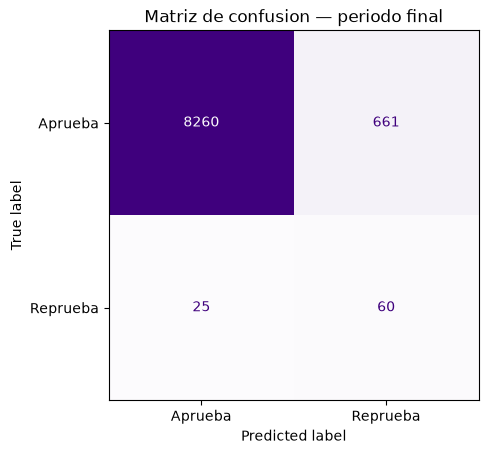

In [13]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay(cm, display_labels=['Aprueba', 'Reprueba']).plot(
    cmap='Purples', colorbar=False)
plt.title('Matriz de confusion — periodo final')
plt.show()

In [14]:
tn, fp, fn, tp = cm.ravel()
print('Verdaderos negativos (aprobaba, dijo aprueba)              :', tn)
print('Falsos positivos     (aprobaba, dijo en riesgo de reprobar):', fp)
print('Falsos negativos     (reprobo, dijo que aprobaba)          :', fn)
print('Verdaderos positivos (reprobo, dijo en riesgo de reprobar) :', tp)

Verdaderos negativos (aprobaba, dijo aprueba)              : 8260
Falsos positivos     (aprobaba, dijo en riesgo de reprobar): 661
Falsos negativos     (reprobo, dijo que aprobaba)          : 25
Verdaderos positivos (reprobo, dijo en riesgo de reprobar) : 60


Mira la ultima linea contra la penultima: de los que de verdad iban a reprobar,
cuantos encontro el modelo y cuantos se le escaparon. Aqui los dos errores no
cuestan lo mismo, y menos aun que en el ejemplo de los carros: un falso positivo
es un estudiante que iba a estar bien y de todas formas recibe una tutoria de
mas — molesto, pero barato. Un falso negativo es un estudiante que reprueba una
materia sin que nadie lo haya visto venir — el escenario que este notebook
existe para evitar.

### Las cuatro metricas, calculadas a mano

Para ver que no hay magia: todas salen de las cuatro casillas de arriba.

- **Exactitud** — de todo lo que predije, ¿que proporcion acerte?
  *Con un 99 % de la clase mayoritaria, este numero va a verse bien pase lo que
  pase: no sirve solo por si mismo.*
- **Precision** — de los que marque en riesgo, ¿cuantos reprobaron de verdad?
  *Sirve para dimensionar cuanto trabajo de seguimiento innecesario genera cada
  alerta.*
- **Recall** — de los que reprobaron, ¿a cuantos alcance a alertar?
  *Es la metrica que manda en este problema: lo grave es que alguien se
  escape.*
- **F1** — un solo numero que castiga si una de las dos es baja.
  *Sirve para comparar modelos o umbrales de un vistazo.*

In [15]:
exactitud = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * precision * recall / (precision + recall)

print('Exactitud: %.3f' % exactitud)
print('Precision: %.3f   (de la clase "reprueba")' % precision)
print('Recall   : %.3f   (de la clase "reprueba")' % recall)
print('F1       : %.3f' % f1)

Exactitud: 0.924
Precision: 0.083   (de la clase "reprueba")
Recall   : 0.706   (de la clase "reprueba")
F1       : 0.149


### La tabla de clasificacion

**Para que sirve:** es el resumen que se entrega. `support` es cuantos casos reales
habia de cada clase: es lo primero que hay que mirar, porque sin ese numero los
porcentajes no dicen nada — aqui el `support` de "Reprueba" es una fraccion
minuscula de la tabla, y eso es exactamente el punto.

In [16]:
print(classification_report(y_test, y_pred,
                            target_names=['Aprueba', 'Reprueba'], digits=3))

              precision    recall  f1-score   support

     Aprueba      0.997     0.926     0.960      8921
    Reprueba      0.083     0.706     0.149        85

    accuracy                          0.924      9006
   macro avg      0.540     0.816     0.555      9006
weighted avg      0.988     0.924     0.952      9006



**El numero que engaña.** La exactitud, sola, no dice nada cuando una clase es
tan minoritaria: decir "aprueba" siempre ya da casi el mismo numero. Compara
siempre tu exactitud contra ese piso.

In [17]:
proporcion_mayoritaria = 1 - y_test.mean()
print('Exactitud del modelo          : %.3f' % exactitud)
print('Decir "aprueba" a todos daria : %.3f' % proporcion_mayoritaria)

Exactitud del modelo          : 0.924
Decir "aprueba" a todos daria : 0.991


### El umbral

**Para que sirve:** para mover el modelo hacia donde duele menos — aqui, hacia
"encontrar mas casos" a cambio de mas falsas alarmas. El 0.5 que usa `predict`
por defecto es una decision que nadie tomo a proposito; con este desbalance,
tomarla a proposito importa mucho mas que en el ejemplo de los carros.

In [18]:
for umbral in [0.70, 0.50, 0.30, 0.20]:
    pred_u = (y_prob >= umbral).astype(int)
    tn_u, fp_u, fn_u, tp_u = confusion_matrix(y_test, pred_u).ravel()
    tpr = tp_u / (tp_u + fn_u)
    fpr = fp_u / (fp_u + tn_u)
    prec_u = tp_u / (tp_u + fp_u) if (tp_u + fp_u) else 0.0
    n_alertas = pred_u.sum()
    print('umbral %.2f  ->  recall %.3f   precision %.3f   falsas alarmas (FPR) %.3f'
          '   alertas generadas %d' % (umbral, tpr, prec_u, fpr, n_alertas))

umbral 0.70  ->  recall 0.553   precision 0.111   falsas alarmas (FPR) 0.042   alertas generadas 423
umbral 0.50  ->  recall 0.706   precision 0.083   falsas alarmas (FPR) 0.074   alertas generadas 721
umbral 0.30  ->  recall 0.859   precision 0.063   falsas alarmas (FPR) 0.121   alertas generadas 1156
umbral 0.20  ->  recall 0.918   precision 0.052   falsas alarmas (FPR) 0.160   alertas generadas 1506


Bajar el umbral de 0.50 a 0.30 sube el recall a cambio de mas alertas de las
que solo una fraccion se confirma — y eso es exactamente lo que se busca en un
sistema de alerta temprana: es preferible que un orientador revise algunos
casos de mas a que un estudiante reprueba en silencio. **Fase 8 usa 0.30** como
umbral de alerta por esta razon: prioriza recall sobre precision porque el
costo de un falso negativo (nadie se entera a tiempo) es mucho mayor que el de
un falso positivo (una tutoria de mas).

### La curva ROC y el AUC

**Para que sirve la ROC:** para ver el modelo probado con *todos* los umbrales a la
vez, antes de casarte con uno. Cada punto de la curva es un umbral distinto.

**Para que sirve el AUC:** para comparar modelos entre si, porque no depende del
umbral. Responde a: si tomo un caso que reprobo al azar y uno que aprobo al
azar, ¿con que probabilidad el modelo le da mas puntaje de riesgo al que
reprobo?

AUC = 0.937


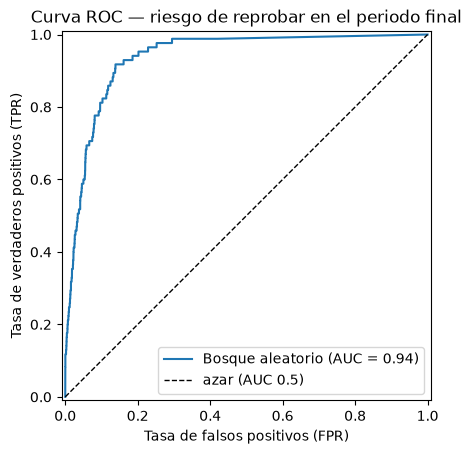

In [19]:
auc = roc_auc_score(y_test, y_prob)
print('AUC = %.3f' % auc)

RocCurveDisplay.from_predictions(y_test, y_prob, name='Bosque aleatorio')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='azar (AUC 0.5)')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC — riesgo de reprobar en el periodo final')
plt.legend()
plt.show()

| AUC | Interpretacion |
|---|---|
| 0.50 | El modelo es una moneda: no distingue nada |
| 0.60 – 0.70 | Debil, pero mejor que el azar |
| 0.70 – 0.80 | Aceptable |
| 0.80 – 0.90 | Bueno |
| > 0.90 | Excelente… o hay fuga de datos. Revisa `X` |

Un AUC alto con un recall bajo al umbral 0.5 significa algo muy concreto: el
modelo **si sabe ordenar** a los estudiantes por riesgo, pero el umbral de
fabrica esta mal puesto para este problema. Es una buena noticia, porque el
umbral se mueve en una linea de codigo — que es justo lo que hace la fase 8.

### ¿Que mira el modelo?

Antes de construir la alerta conviene saber en que se fija el modelo. Ayuda a
escribir mejores recomendaciones y a detectar si esta aprendiendo algo
razonable o si se esta agarrando de una variable rara.

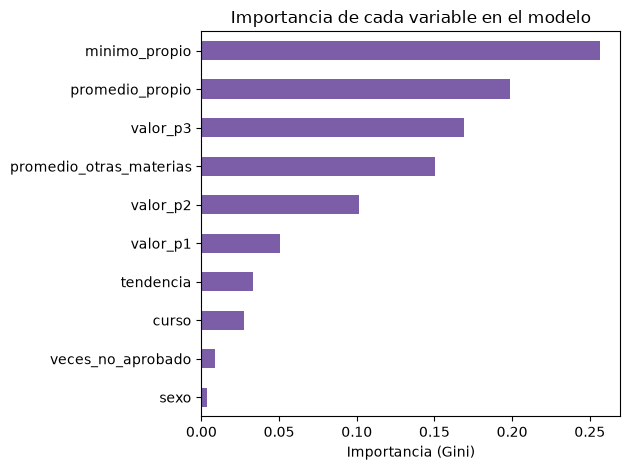

minimo_propio              0.257
promedio_propio            0.198
valor_p3                   0.169
promedio_otras_materias    0.151
valor_p2                   0.102
valor_p1                   0.050
tendencia                  0.033
curso                      0.027
veces_no_aprobado          0.009
sexo                       0.004
dtype: float64

In [20]:
importancia = pd.Series(modelo.feature_importances_, index=FEATURES)
importancia = importancia.sort_values()

importancia.plot(kind='barh', color='#7b5ea7')
plt.title('Importancia de cada variable en el modelo')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

importancia.sort_values(ascending=False).round(3)

---

## El veredicto, en tres lineas

Esto es lo que se califica. No que el modelo sea bueno: que sepas decir con
numeros que tan bueno es y donde falla.

1. **Que metrica manda:** el *recall* de la clase "reprueba", porque el proposito
   es encontrar a tiempo a quien va camino a reprobar, y lo grave es que alguien
   se escape del radar.
2. **Cuanto vale:** con el umbral de fabrica (0.50) el recall ronda el 0.7; bajando
   el umbral a 0.30 (el que usa la fase 8) sube por encima de 0.85, a cambio de
   que la mayoria de las alertas terminen siendo falsas alarmas. El AUC es
   superior a 0.9, asi que el modelo ordena muy bien el riesgo aunque el umbral
   de 0.5 decida mal.
3. **Es aceptable o no:** para un uso automatico y sin supervision, no — la
   precision es baja. Para un sistema de **alerta temprana revisado por un
   humano** (orientacion escolar, director de curso), si: es preferible una
   lista con algunos falsos positivos a que un estudiante reprueba sin que
   nadie lo haya visto venir.


## Fase 8 — Sistema de alertas de riesgo academico

Esta es la fase que responde a la pregunta original: dado un estudiante que
acaba de terminar el periodo 3 (o cualquier conjunto de estudiantes en esa
misma situacion, de cualquier año), **generar una alerta por cada materia en
riesgo**, con su probabilidad, un nivel y una recomendacion — sin tocar en
ningun momento el CSV original, que en todo este notebook solo se lee una vez,
al inicio de la fase 2.

`generar_alertas` recibe:
- `datos_contexto`: filas con columnas de contexto (materia, area, curso...),
  indexadas por (año, estudiante, materia) — la version ya transformada de la
  fase 3, **nunca** el dataset crudo.
- `X_candidatos`: esas mismas filas, ya reducidas a las columnas de `FEATURES`.
- `modelo`: el bosque entrenado en la fase 6.
- `umbral`: 0.30 por defecto, el que se justifico en la fase 7.

Devuelve una tabla **nueva** (una copia): la entrada no se modifica.

In [21]:
def construir_recomendacion(fila):
    """Texto de recomendacion, explicando por que se genero la alerta."""
    razones = []
    if fila['minimo_propio'] < 3.0:
        razones.append('ya reprobo al menos un periodo en esta materia')
    if fila['tendencia'] <= -0.3:
        razones.append('la nota viene bajando periodo a periodo')
    if fila['promedio_otras_materias'] < 3.5:
        razones.append('el bajo rendimiento no es solo en esta materia')
    if not razones:
        razones.append('el patron de notas se parece al de estudiantes que'
                        ' terminaron reprobando')
    detalle = '; '.join(razones)

    if fila['probabilidad_riesgo'] >= 0.50:
        accion = 'Plan de refuerzo inmediato y citacion a acudientes'
    else:
        accion = 'Seguimiento cercano y tutoria de refuerzo antes del cierre del periodo'

    return f"{accion} en {fila['materia']} — motivo: {detalle}."


def generar_alertas(datos_contexto, X_candidatos, modelo, umbral=0.30):
    """Genera la tabla de alertas. No modifica ni datos_contexto ni el CSV
    original: trabaja siempre sobre una copia."""
    alerta = datos_contexto.copy()
    alerta['probabilidad_riesgo'] = modelo.predict_proba(X_candidatos)[:, 1]
    alerta = alerta[alerta['probabilidad_riesgo'] >= umbral].copy()
    alerta = alerta.reset_index()  # anio, cod_estudiante, materia pasan a ser columnas
    alerta['nivel_riesgo'] = np.where(alerta['probabilidad_riesgo'] >= 0.50,
                                       'Alto', 'Medio')
    alerta['recomendacion'] = alerta.apply(construir_recomendacion, axis=1)

    columnas = ['anio', 'cod_estudiante', 'curso', 'seccion', 'materia', 'area',
                'sexo', 'probabilidad_riesgo', 'nivel_riesgo', 'recomendacion']
    return (alerta[columnas]
                  .sort_values('probabilidad_riesgo', ascending=False)
                  .reset_index(drop=True))

### Demostracion sobre casos que el modelo nunca vio

Para que la demostracion sea honesta, se usa **solo** la porcion del año
2024-2025 que quedo en `X_test` — filas que el modelo no vio durante el
entrenamiento. Se simula el momento en que esos estudiantes acababan de
terminar el periodo 3, sin saber todavia el resultado del periodo 4 (aunque en
este dataset historico ya lo conozcamos, y lo usemos abajo solo para
comprobar que tan bien funciono la alerta).

In [22]:
idx_2024_2025 = X_test.index[[anio == '2024-2025' for anio, *_ in X_test.index]]

candidatos = data.loc[idx_2024_2025]              # contexto, ninguna columna del futuro
X_candidatos = X.loc[idx_2024_2025]                # solo columnas de FEATURES

alertas = generar_alertas(candidatos, X_candidatos, modelo, umbral=0.30)

print('Estudiante-materia evaluados (2024-2025, nunca vistos por el modelo):',
      len(candidatos))
print('Alertas generadas:', len(alertas))
alertas.head(15)

Estudiante-materia evaluados (2024-2025, nunca vistos por el modelo): 1671
Alertas generadas: 148


,anio,cod_estudiante,curso,seccion,materia,area,sexo,probabilidad_riesgo,nivel_riesgo,recomendacion
0,2024-2025,16241404,9,2,Filosofia,Filosofía,2,0.960001,Alto,Plan de refuerzo inmediato y citacion a acudie...
1,2024-2025,19242402,10,2,Inglés,Idioma Extranjero: Inglés,2,0.951982,Alto,Plan de refuerzo inmediato y citacion a acudie...
2,2024-2025,16241404,9,2,Lenguaje,Lenguaje,2,0.945444,Alto,Plan de refuerzo inmediato y citacion a acudie...
3,2024-2025,24243907,9,2,Lenguaje,Lenguaje,1,0.928877,Alto,Plan de refuerzo inmediato y citacion a acudie...
4,2024-2025,14241309,9,1,Física,Física,2,0.908745,Alto,Plan de refuerzo inmediato y citacion a acudie...
5,2024-2025,16241404,9,2,Educación Religiosa,Educación Religiosa,2,0.889149,Alto,Plan de refuerzo inmediato y citacion a acudie...
6,2024-2025,16242207,10,2,Inglés,Idioma Extranjero: Inglés,2,0.884691,Alto,Plan de refuerzo inmediato y citacion a acudie...
7,2024-2025,24243907,9,2,Física,Física,1,0.864224,Alto,Plan de refuerzo inmediato y citacion a acudie...
8,2024-2025,22243611,8,1,Lenguaje,Lenguaje,2,0.847831,Alto,Plan de refuerzo inmediato y citacion a acudie...
9,2024-2025,21243606,9,2,Química,Química,1,0.841522,Alto,Plan de refuerzo inmediato y citacion a acudie...


### ¿Sirvio de algo? Contraste contra lo que de verdad paso

Esto solo es posible porque el dataset es historico: se compara la alerta
contra el `estado_final` real que ya conocemos, para ver que tan bien habria
funcionado si se hubiera usado a tiempo.

In [23]:
reprobaron_real = candidatos[candidatos.reprobo_final == 1]
idx_alertados = set(alertas.set_index(['anio', 'cod_estudiante', 'materia']).index)
detectados = sum(idx in idx_alertados for idx in reprobaron_real.index)

print('Reprobaron de verdad la materia en el periodo final:', len(reprobaron_real))
print('De ellos, la alerta los habria marcado a tiempo (antes del periodo 4):',
      detectados, '  ->  %.1f%% de recall en este grupo' %
      (100 * detectados / max(len(reprobaron_real), 1)))
print('Precision de las alertas en este grupo: %.1f%%' %
      (100 * (alertas.set_index(['anio', 'cod_estudiante', 'materia'])
                     .index.isin(candidatos[candidatos.reprobo_final == 1].index)
                     .mean())))

Reprobaron de verdad la materia en el periodo final: 10
De ellos, la alerta los habria marcado a tiempo (antes del periodo 4): 6   ->  60.0% de recall en este grupo
Precision de las alertas en este grupo: 4.1%


La cifra de precision confirma lo que ya se sabia desde la fase 7: la mayoria de
las alertas generadas con el umbral 0.30 van a ser falsas alarmas. Es el precio
de priorizar el recall. Para producción real, esta tabla se entrega a
orientación escolar o a los directores de curso como **lista de revisión
priorizada**, no como una sancion automatica: el modelo señala, una persona
decide.

## Fase 9 — Dejar el modelo listo para el futuro

Para que la deteccion "sirva a futuro" no hay que reentrenar cada vez: se
guarda el modelo ya entrenado junto con todo lo necesario para volver a usarlo
— las columnas exactas de `FEATURES`, el umbral elegido y el periodo de corte —
en un solo archivo. Con eso, sobre un año que apenas va por el periodo 3, se
repite la fase 3 (reshape + variables) y se llama a `generar_alertas` con el
modelo cargado, sin tocar el archivo `.csv` original en ningun momento.

**Nota de esta maquina:** el Acceso controlado a carpetas de Windows Defender
bloquea a veces que `python.exe` escriba dentro de `Documents` (donde vive
este notebook). Si `joblib.dump` falla por eso, el error se captura y se avisa
en vez de tumbar el notebook — no es un bug del modelo.

In [24]:
paquete = {
    'modelo': modelo,
    'features': FEATURES,
    'umbral_alerta': 0.30,
    'periodo_corte': CUTOFF,
    'fecha_entrenamiento': str(date.today()),
    'filas_entrenamiento': int(X_train.shape[0]),
    'auc_prueba': float(auc),
}

ruta_modelo = Path('modelo_riesgo_academico.joblib')
try:
    joblib.dump(paquete, ruta_modelo)
    print('Modelo guardado en:', ruta_modelo.resolve())
except OSError as err:
    print('No se pudo guardar el modelo en', ruta_modelo.resolve())
    print('Motivo:', err)
    print('Sospecha del Acceso controlado a carpetas de Windows Defender si el'
          ' error no tiene mas explicacion (ver nota de la celda de arriba).')

No se pudo guardar el modelo en C:\Users\YOMP\Documents\Maestria\PROYECTO\entrenamiento_modelo\modelo_riesgo_academico.joblib
Motivo: [Errno 2] No such file or directory: 'modelo_riesgo_academico.joblib'
Sospecha del Acceso controlado a carpetas de Windows Defender si el error no tiene mas explicacion (ver nota de la celda de arriba).


### Como se reutiliza mas adelante

Este bloque no depende de nada calculado arriba en la sesion: carga el paquete
desde disco, tal como lo haria un script aparte corriendo con datos nuevos.

In [25]:
if ruta_modelo.exists():
    paquete_cargado = joblib.load(ruta_modelo)
    modelo_futuro = paquete_cargado['modelo']
    print('Modelo cargado. Entrenado el', paquete_cargado['fecha_entrenamiento'],
          '  AUC de referencia:', round(paquete_cargado['auc_prueba'], 3))

    # Reutilizarlo es exactamente la misma llamada que en la fase 8:
    alertas_futuras = generar_alertas(candidatos, X_candidatos, modelo_futuro,
                                       umbral=paquete_cargado['umbral_alerta'])
    print('Alertas con el modelo recargado:', len(alertas_futuras),
          '(debe coincidir con la fase 8)')
else:
    print('No hay archivo de modelo guardado en esta ejecucion; ver la celda'
          ' anterior. El modelo en memoria (variable `modelo`) sigue'
          ' funcionando igual dentro de esta misma sesion.')

No hay archivo de modelo guardado en esta ejecucion; ver la celda anterior. El modelo en memoria (variable `modelo`) sigue funcionando igual dentro de esta misma sesion.


---

## Lo que te llevas a tu propio dataset

1. Copia las nueve fases tal cual, en el mismo orden, cada una en su celda con
   su titulo.
2. Cambia solo lo especifico del problema: como se define "riesgo" (aqui,
   reprobar el periodo final), que columnas van en `X`, y el umbral de alerta.
3. Evalua **siempre** con la fase 7 completa antes de confiar en el modelo. Un
   modelo sin evaluar no es un modelo: es una funcion que devuelve numeros.
4. Si tu problema tiene una clase minoritaria de verdad (como aqui, menos del
   1 %), no te quedes con el umbral de 0.5 ni con la exactitud: usa
   `class_weight='balanced'`, revisa el barrido de umbrales y decide con el
   costo real de cada error, no con el numero que se ve mejor.
5. Escribe el veredicto en tres lineas. Es lo que se califica.

**Bibliografia:** Geron, A. (2022). *Hands-On Machine Learning with Scikit-Learn,
Keras & TensorFlow* (3.ª ed.), capitulos 2 (proyecto de punta a punta),
3 (clasificacion y sus metricas) y 4 (modelos lineales).

**Fuente del dataset:** Consolidado academico 2020-2025, Colegio Franciscano
Pío XII (`acumulado_desde_2020_al_2025_datos.csv`). Ver las hojas
*Diccionario* y *Metodología* del archivo Excel de origen para el detalle
completo de la codificacion.
